<a href="https://colab.research.google.com/github/Ragul-S-2025/ML/blob/main/hEART_DESEASE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import os

zip1_path = "/content/archive (6).zip"
zip2_path = "/content/archive (5).zip"

extract_path1 = "/mnt/data/dataset1"
extract_path2 = "/mnt/data/dataset2"

os.makedirs(extract_path1, exist_ok=True)
os.makedirs(extract_path2, exist_ok=True)

with zipfile.ZipFile(zip1_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path1)

with zipfile.ZipFile(zip2_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path2)

print("Extraction Complete")


Extraction Complete


In [2]:
import pandas as pd
import glob

files1 = glob.glob(extract_path1 + "/*.csv")
files2 = glob.glob(extract_path2 + "/*.csv")

df1 = pd.read_csv(files1[0])
df2 = pd.read_csv(files2[0])

print("Dataset1 Shape:", df1.shape)
print("Dataset2 Shape:", df2.shape)


Dataset1 Shape: (1025, 14)
Dataset2 Shape: (303, 14)


In [3]:
print(df1.head())
print(df2.head())

print(df1.info())
print(df2.info())


   age     sex chest_pain_type  resting_blood_pressure  cholestoral  \
0   52    Male  Typical angina                     125          212   
1   53    Male  Typical angina                     140          203   
2   70    Male  Typical angina                     145          174   
3   61    Male  Typical angina                     148          203   
4   62  Female  Typical angina                     138          294   

      fasting_blood_sugar               rest_ecg  Max_heart_rate  \
0    Lower than 120 mg/ml  ST-T wave abnormality             168   
1  Greater than 120 mg/ml                 Normal             155   
2    Lower than 120 mg/ml  ST-T wave abnormality             125   
3    Lower than 120 mg/ml  ST-T wave abnormality             161   
4  Greater than 120 mg/ml  ST-T wave abnormality             106   

  exercise_induced_angina  oldpeak        slope vessels_colored_by_flourosopy  \
0                      No      1.0  Downsloping                           Two   
1 

In [4]:
df2 = df2.rename(columns={
    "cp": "chest_pain_type",
    "trestbps": "resting_blood_pressure",
    "chol": "cholestoral",
    "fbs": "fasting_blood_sugar",
    "restecg": "rest_ecg",
    "thalach": "Max_heart_rate",
    "exang": "exercise_induced_angina",
    "ca": "vessels_colored_by_flourosopy",
    "thal": "thalassemia",
    "num": "target"
})


In [5]:
# Convert sex
df2["sex"] = df2["sex"].map({1: "Male", 0: "Female"})

# Convert fasting blood sugar
df2["fasting_blood_sugar"] = df2["fasting_blood_sugar"].map({
    1: "Greater than 120 mg/ml",
    0: "Lower than 120 mg/ml"
})

# Convert exercise angina
df2["exercise_induced_angina"] = df2["exercise_induced_angina"].map({
    1: "Yes",
    0: "No"
})

# Convert target (important)
df2["target"] = df2["target"].apply(lambda x: 1 if x > 0 else 0)


In [6]:
df2 = df2[df1.columns]

In [7]:
df = pd.concat([df1, df2], axis=0, ignore_index=True)

print("Merged Shape:", df.shape)


Merged Shape: (1328, 14)


In [8]:
df = pd.get_dummies(df, drop_first=True)


In [9]:
X = df.drop("target", axis=1)
y = df["target"]


In [10]:
import numpy as np

def cap_outliers_iqr(data):
    for col in data.select_dtypes(include=np.number).columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        data[col] = np.where(data[col] < lower, lower, data[col])
        data[col] = np.where(data[col] > upper, upper, data[col])

    return data

X = cap_outliers_iqr(X)


In [11]:
from scipy.stats import skew

skewness = X.apply(lambda x: skew(x))

skewed_cols = skewness[abs(skewness) > 1].index

for col in skewed_cols:
    X[col] = np.log1p(X[col])


In [12]:
import pandas as pd

corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

X = X.drop(columns=to_drop)

print("Dropped Columns:", to_drop)


Dropped Columns: []


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [14]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [15]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [16]:
from xgboost import XGBClassifier

model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)


In [17]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [400, 600, 800],
    "max_depth": [4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.2],
    "reg_alpha": [0, 0.5, 1],
    "reg_lambda": [1, 1.5, 2]
}

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=40,
    scoring="accuracy",
    cv=skf,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("Best Params:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Params: {'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 0.5, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.03, 'gamma': 0.2, 'colsample_bytree': 0.8}
Best CV Accuracy: 0.9303348392240235


In [18]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))


Accuracy: 0.943609022556391
ROC AUC: 0.9853015998643223
              precision    recall  f1-score   support

           0       0.91      0.98      0.95       133
           1       0.98      0.90      0.94       133

    accuracy                           0.94       266
   macro avg       0.95      0.94      0.94       266
weighted avg       0.95      0.94      0.94       266



In [19]:
import numpy as np

thresholds = np.arange(0.3, 0.7, 0.01)
best_acc = 0
best_thresh = 0.5

for t in thresholds:
    preds = (y_prob >= t).astype(int)
    acc = accuracy_score(y_test, preds)
    if acc > best_acc:
        best_acc = acc
        best_thresh = t

print("Optimal Threshold:", best_thresh)
print("Optimized Accuracy:", best_acc)


Optimal Threshold: 0.34
Optimized Accuracy: 0.9624060150375939


In [20]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.943609022556391
ROC AUC: 0.9853015998643223
              precision    recall  f1-score   support

           0       0.91      0.98      0.95       133
           1       0.98      0.90      0.94       133

    accuracy                           0.94       266
   macro avg       0.95      0.94      0.94       266
weighted avg       0.95      0.94      0.94       266



In [21]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)


Best Threshold: 0.36274505


In [22]:
y_pred_opt = (y_prob >= best_threshold).astype(int)

from sklearn.metrics import accuracy_score
print("New Accuracy:", accuracy_score(y_test, y_pred_opt))


New Accuracy: 0.9624060150375939


In [23]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy:", accuracy_score(y_test, y_pred_opt))
print("Precision:", precision_score(y_test, y_pred_opt))
print("Recall:", recall_score(y_test, y_pred_opt))
print("F1 Score:", f1_score(y_test, y_pred_opt))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_opt))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_opt))


Accuracy: 0.9624060150375939
Precision: 0.9624060150375939
Recall: 0.9624060150375939
F1 Score: 0.9624060150375939
ROC AUC: 0.9853015998643223

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       133
           1       0.96      0.96      0.96       133

    accuracy                           0.96       266
   macro avg       0.96      0.96      0.96       266
weighted avg       0.96      0.96      0.96       266


Confusion Matrix:

[[128   5]
 [  5 128]]


In [24]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm.ravel()

# Metrics
accuracy = accuracy_score(y_test, y_pred_opt)
precision = precision_score(y_test, y_pred_opt)
recall = recall_score(y_test, y_pred_opt)
f1 = f1_score(y_test, y_pred_opt)
specificity = tn / (tn + fp)

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Specificity": specificity
}


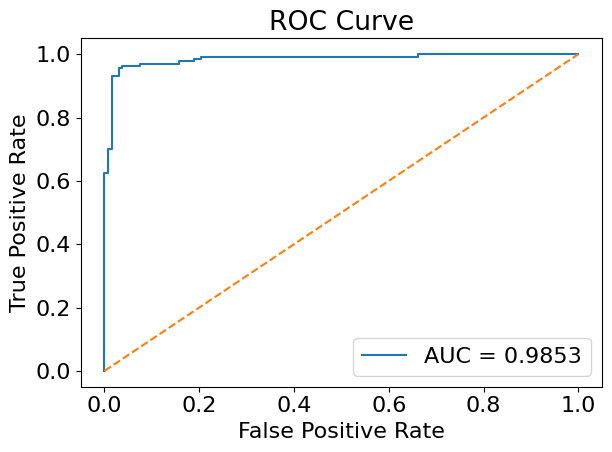

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("ROC_Curve.png", dpi=300)
plt.show()


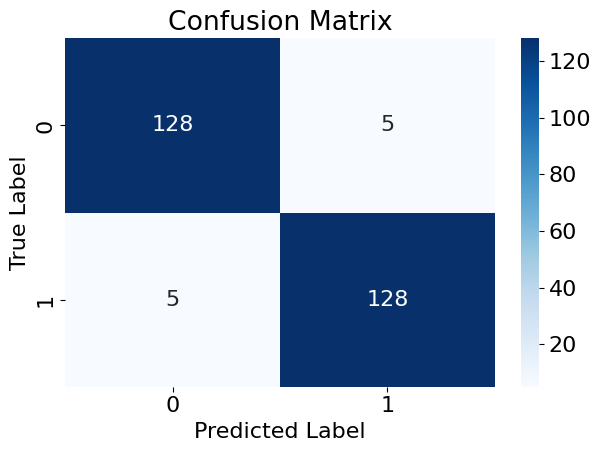

In [26]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_opt)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("Confusion_Matrix.png", dpi=300)
plt.show()


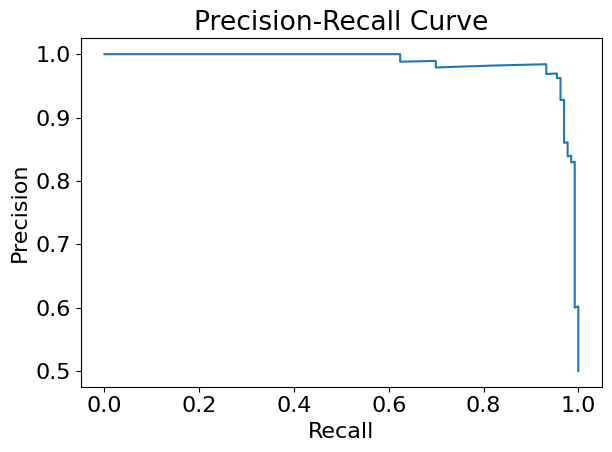

In [27]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall_vals, precision_vals)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.savefig("Precision_Recall_Curve.png", dpi=300)
plt.show()


<Figure size 640x480 with 0 Axes>

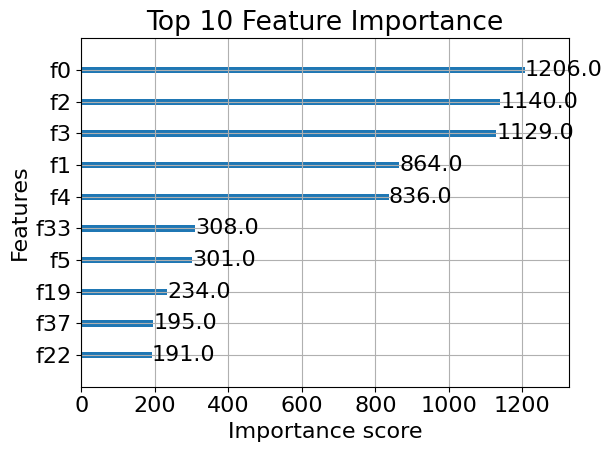

In [28]:
from xgboost import plot_importance

plt.figure()
plot_importance(best_model, max_num_features=10)
plt.title("Top 10 Feature Importance")
plt.tight_layout()
plt.savefig("Feature_Importance.png", dpi=300)
plt.show()


In [29]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred_opt)
precision = precision_score(y_test, y_pred_opt)
recall = recall_score(y_test, y_pred_opt)
f1 = f1_score(y_test, y_pred_opt)
specificity = tn / (tn + fp)


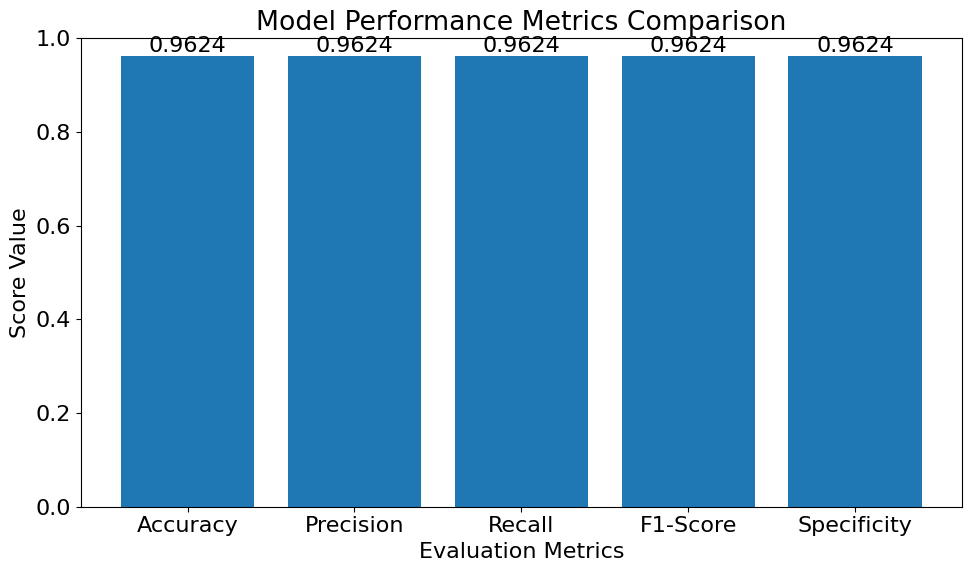

In [30]:
import matplotlib.pyplot as plt
import os

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16

metrics_names = ["Accuracy", "Precision", "Recall", "F1-Score", "Specificity"]
metrics_values = [accuracy, precision, recall, f1, specificity]

plt.figure(figsize=(10,6))

bars = plt.bar(metrics_names, metrics_values)

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score Value")
plt.title("Model Performance Metrics Comparison")
plt.ylim(0, 1)

# Show values above bars
for i, v in enumerate(metrics_values):
    plt.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=16)

plt.tight_layout()
plt.savefig("Model_Performance_Metrics.png", dpi=300)
plt.show()
